In [1]:
!unzip -q /content/data.zip -d /content/custom_data

In [2]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py


!python train_val_split.py --datapath="/content/custom_data" --train_pct=0.9

--2026-05-11 13:52:34--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2026-05-11 13:52:34 (46.0 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 1726
Number of annotation files: 1730
Images moving to train: 1553
Images moving to validation: 173


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.8 MB/s eta 0:00:00


In [4]:
import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):


  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)


  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }


  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return


path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 15
names:
- acucar_1kg
- arroz_1kg
- arroz_5kg
- cafe_250g
- cafe_500g
- feijao_1kg
- feijao_500g
- fuba_1kg
- fuba_500g
- leite_em_po_1kg
- leite_em_po_400g
- macarrao_500g
- molho_de_tomate_240g
- oleo_900ml
- peixe_enlatado_120g


In [5]:
!yolo detect train data=/content/data.yaml model=yolov8n.pt epochs=200 imgsz=768 patience=35

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, 

In [6]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=data/validation/images save=True

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs

image 1/173 /content/data/validation/images/00a6c3c8-D_NQ_NP_2X_963572-MLA98786471091_112025-F.webp: 768x576 1 arroz_1kg, 1 leite_em_po_400g, 48.5ms
image 2/173 /content/data/validation/images/00e6de0a-D_NQ_NP_2X_800765-MLA98820601178_112025-F.webp: 768x576 1 leite_em_po_400g, 7.3ms
image 3/173 /content/data/validation/images/091ee141-D_NQ_NP_2X_827031-MLA105987457857_012026-F.webp: 768x384 2 cafe_500gs, 43.7ms
image 4/173 /content/data/validation/images/0a5d6fcd-br-11134103-7r98o-m5fzpx5sci1c66.webp: 768x448 2 acucar_1kgs, 37.8ms
image 5/173 /content/data/validation/images/0a5dc74c-D_NQ_NP_2X_644545-MLA98908356884_112025-F.webp: 768x448 1 cafe_250g, 6.9ms
image 6/173 /content/data/validation/images/0af9e295-D_NQ_NP_2X_989339-MLA107823796039_022026-F.webp: 768x448 1 leite_em_po_400g, 9.3ms
image 7/173 /content/data/validatio

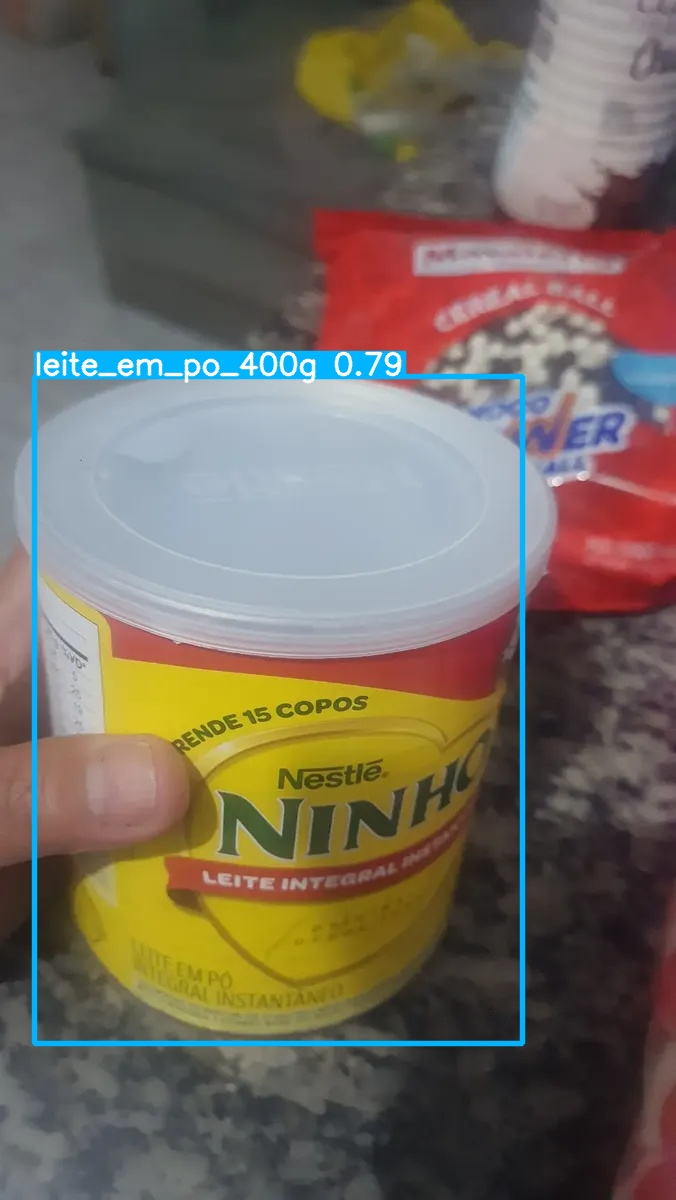

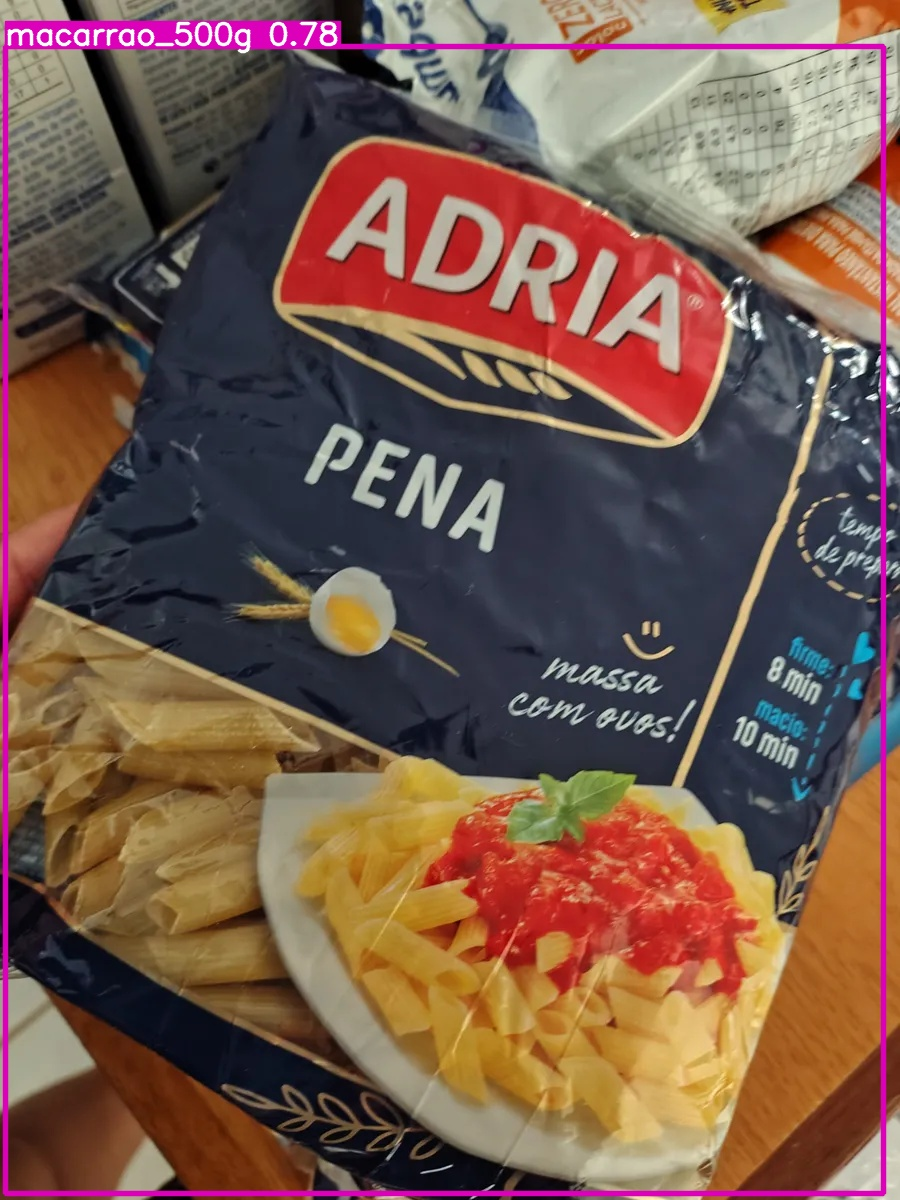

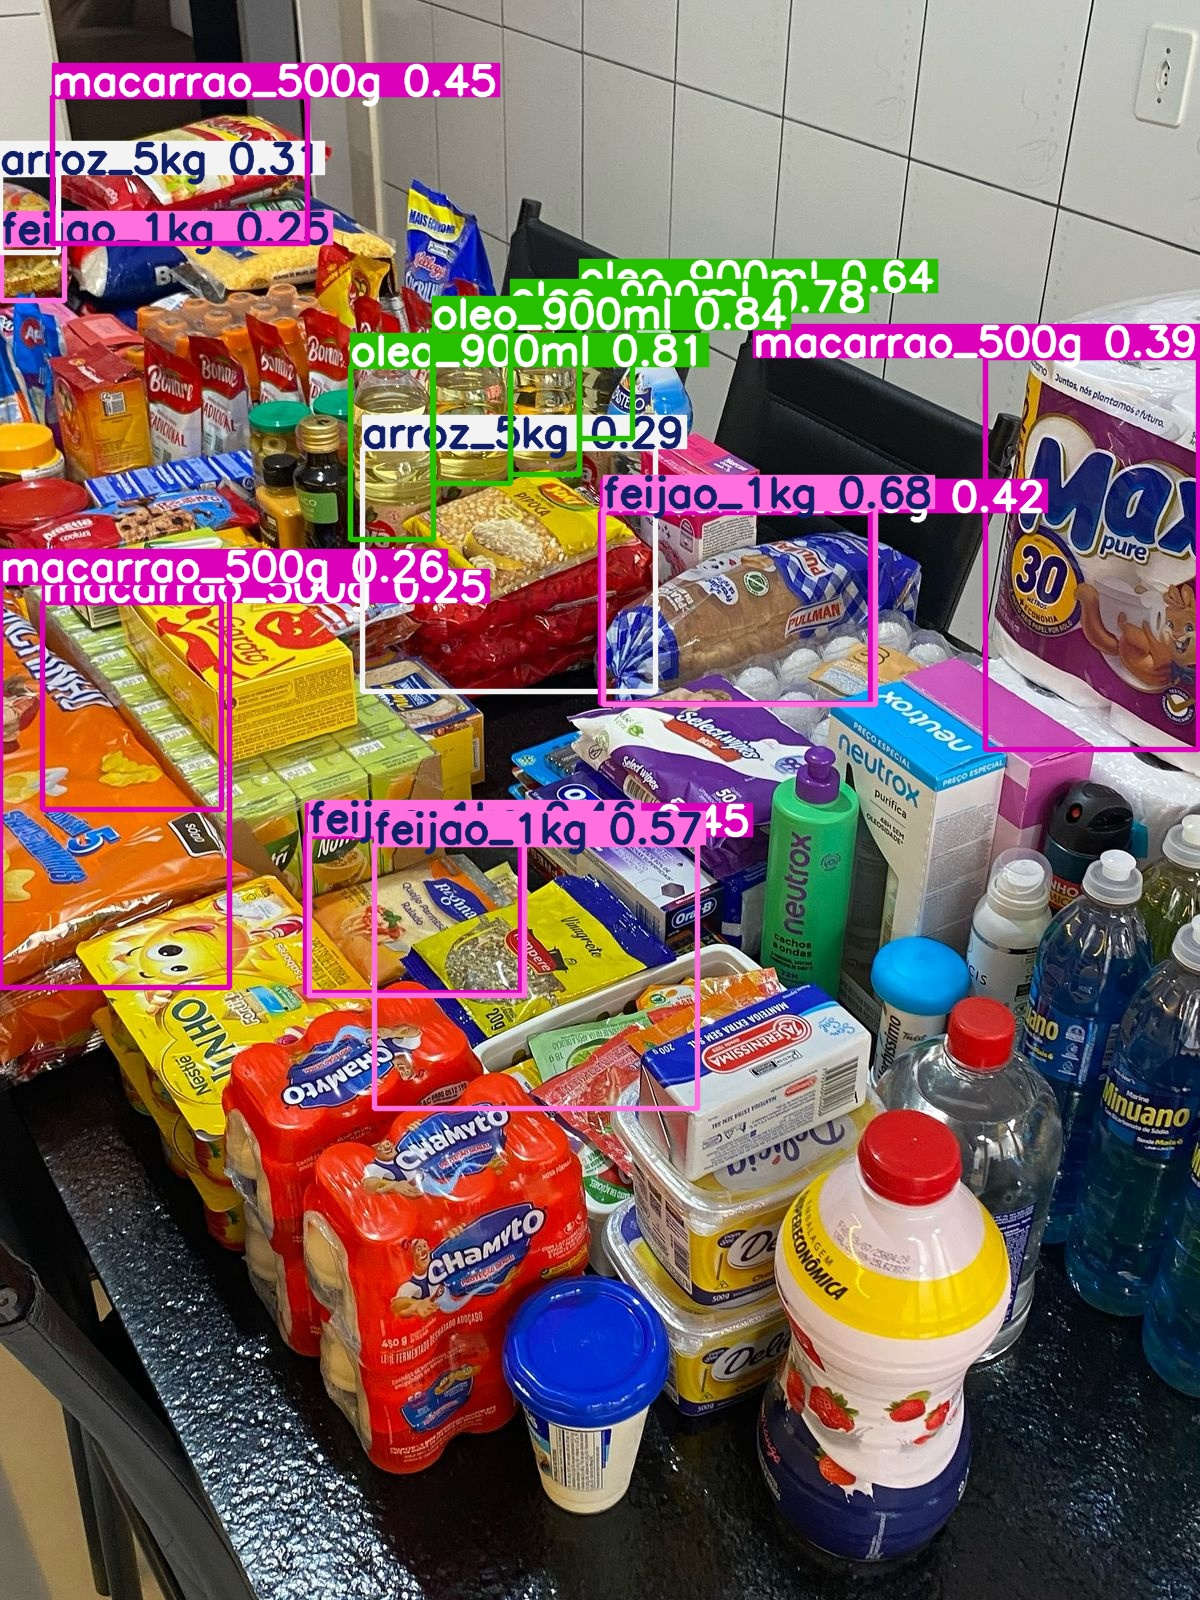

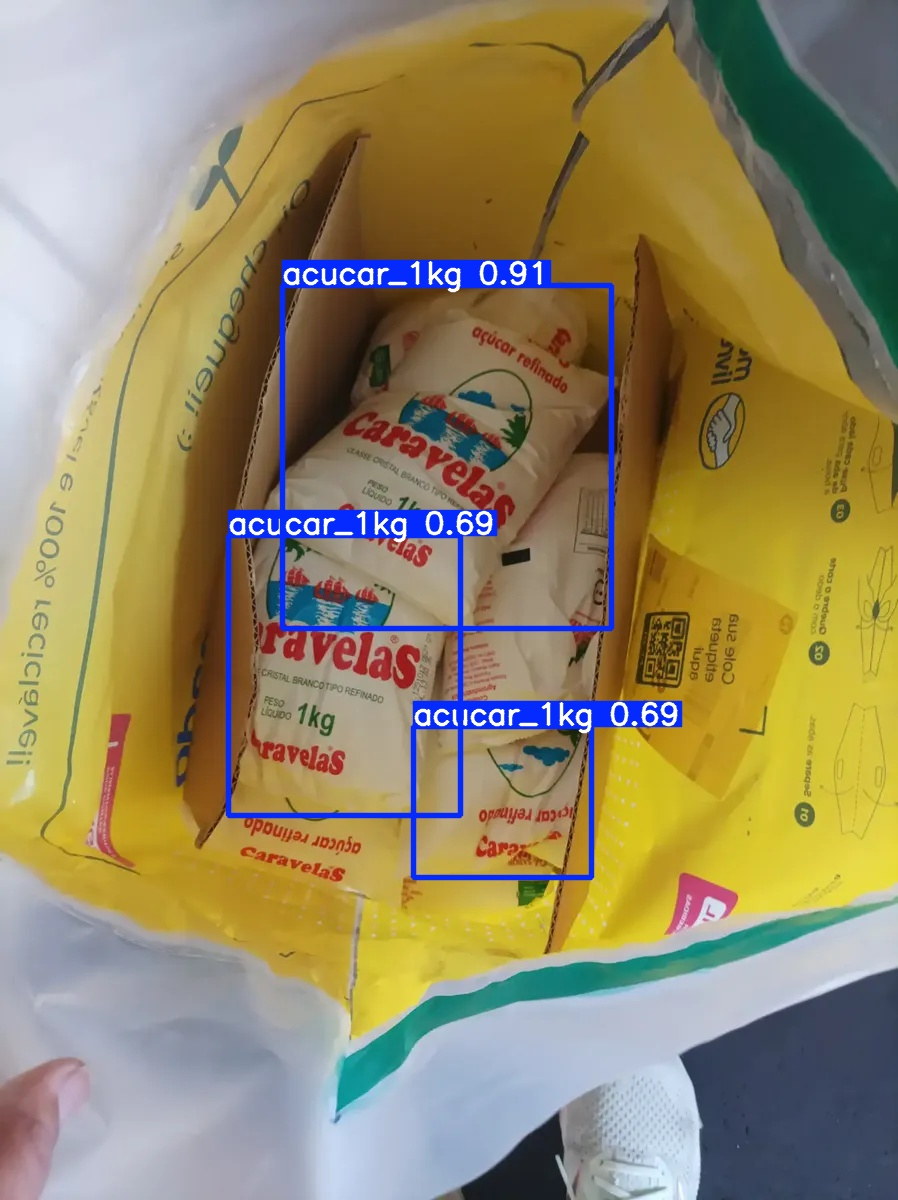

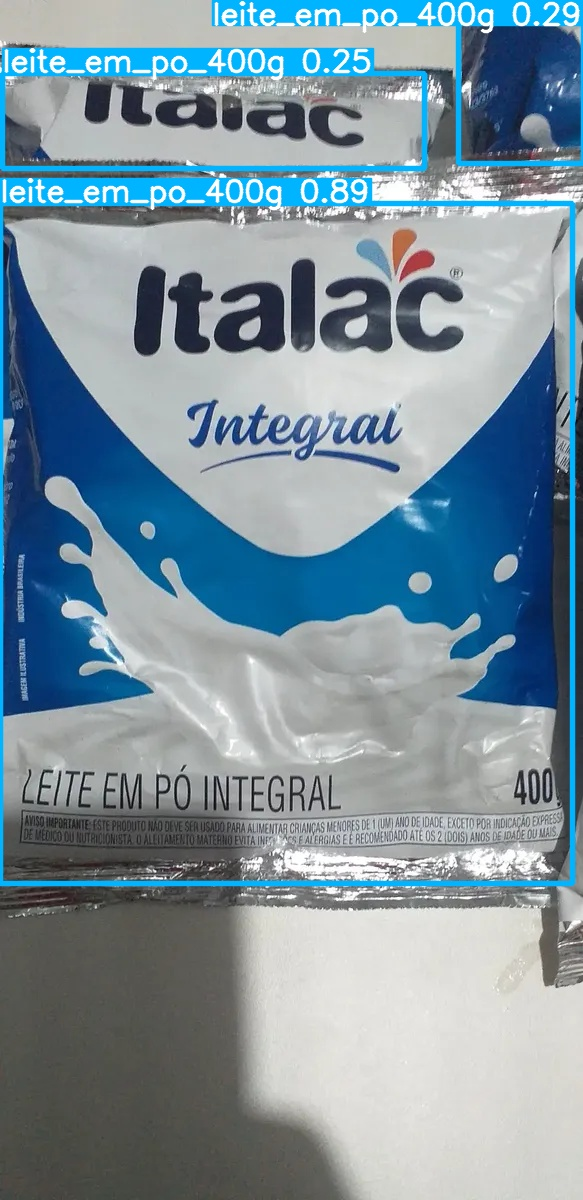

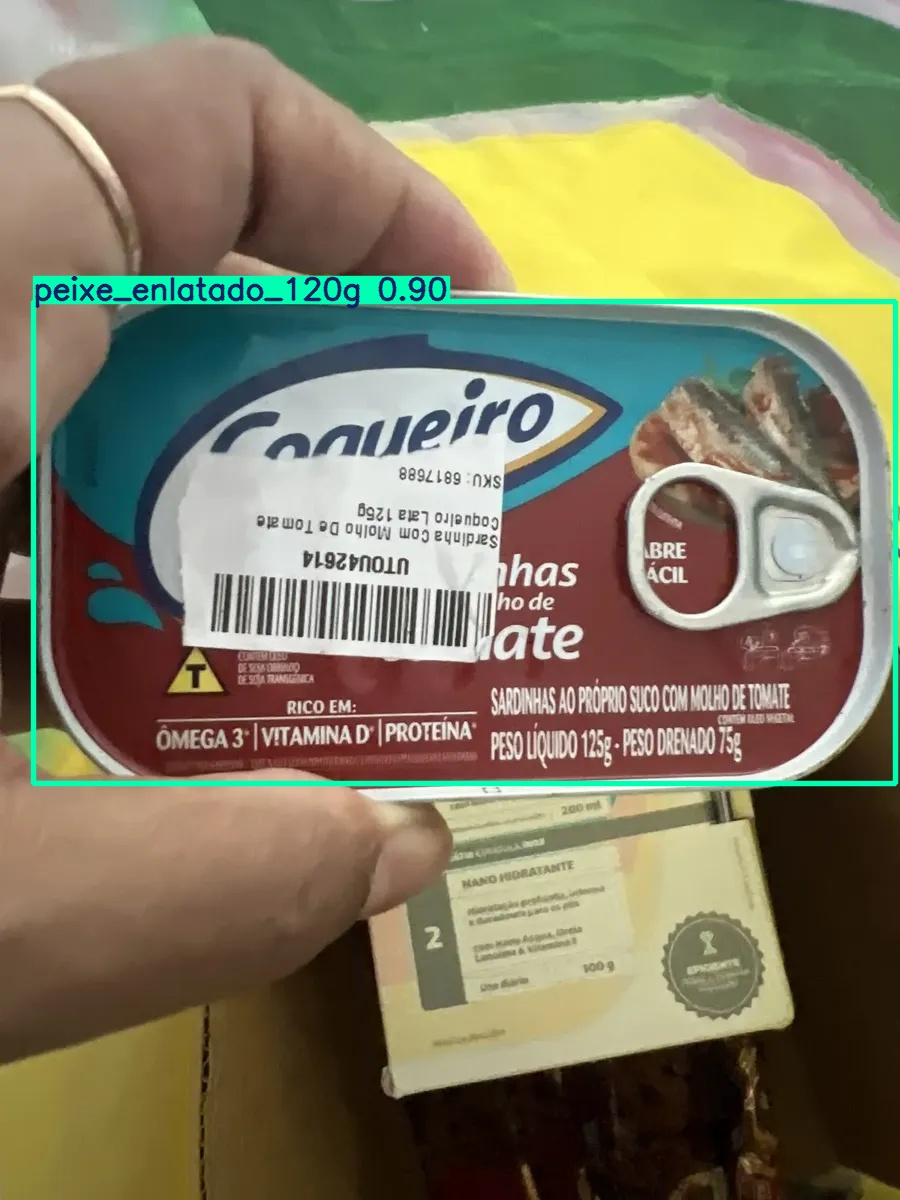

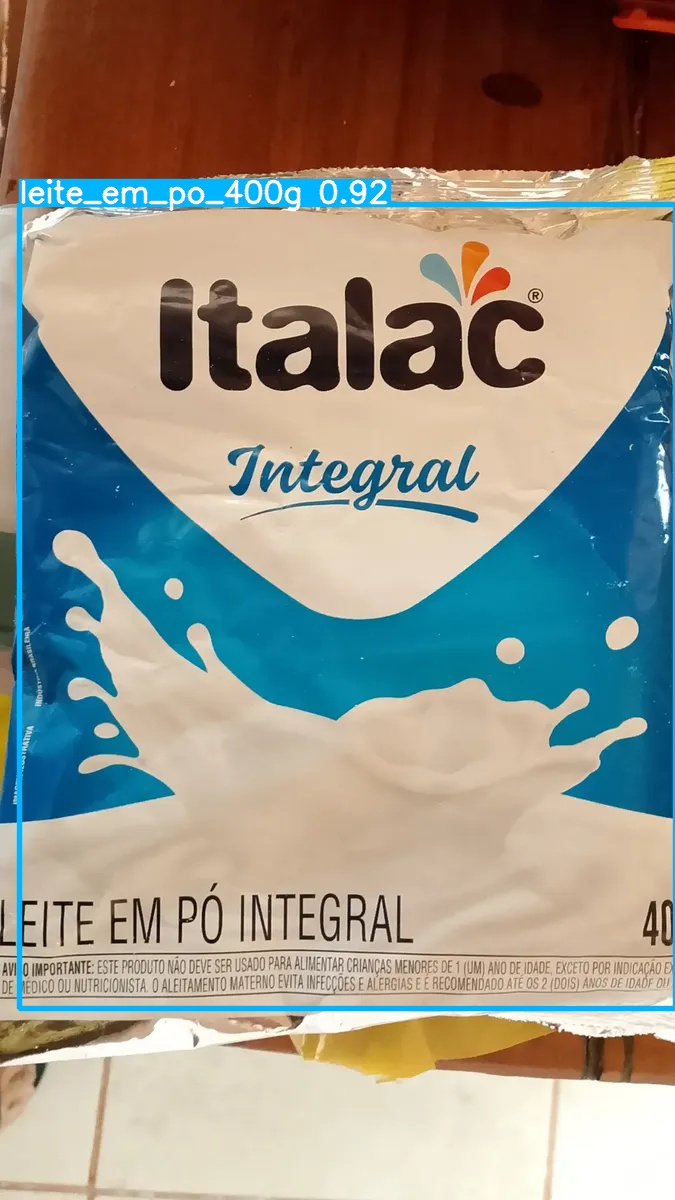

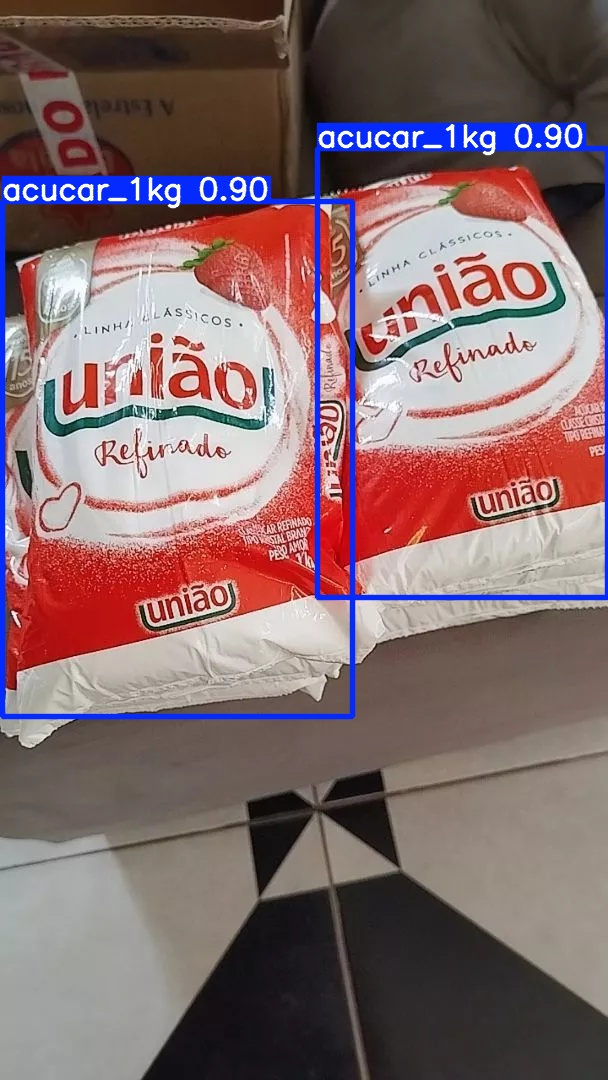

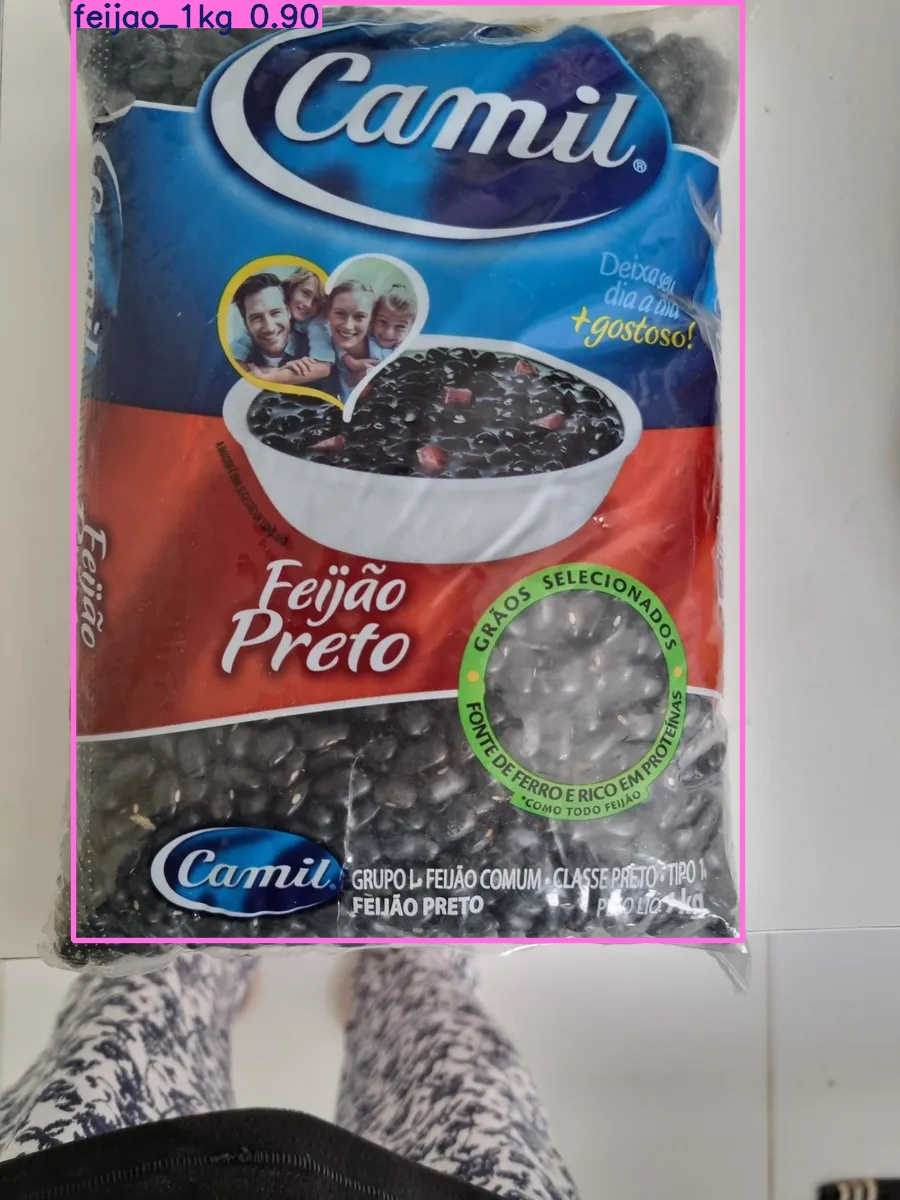

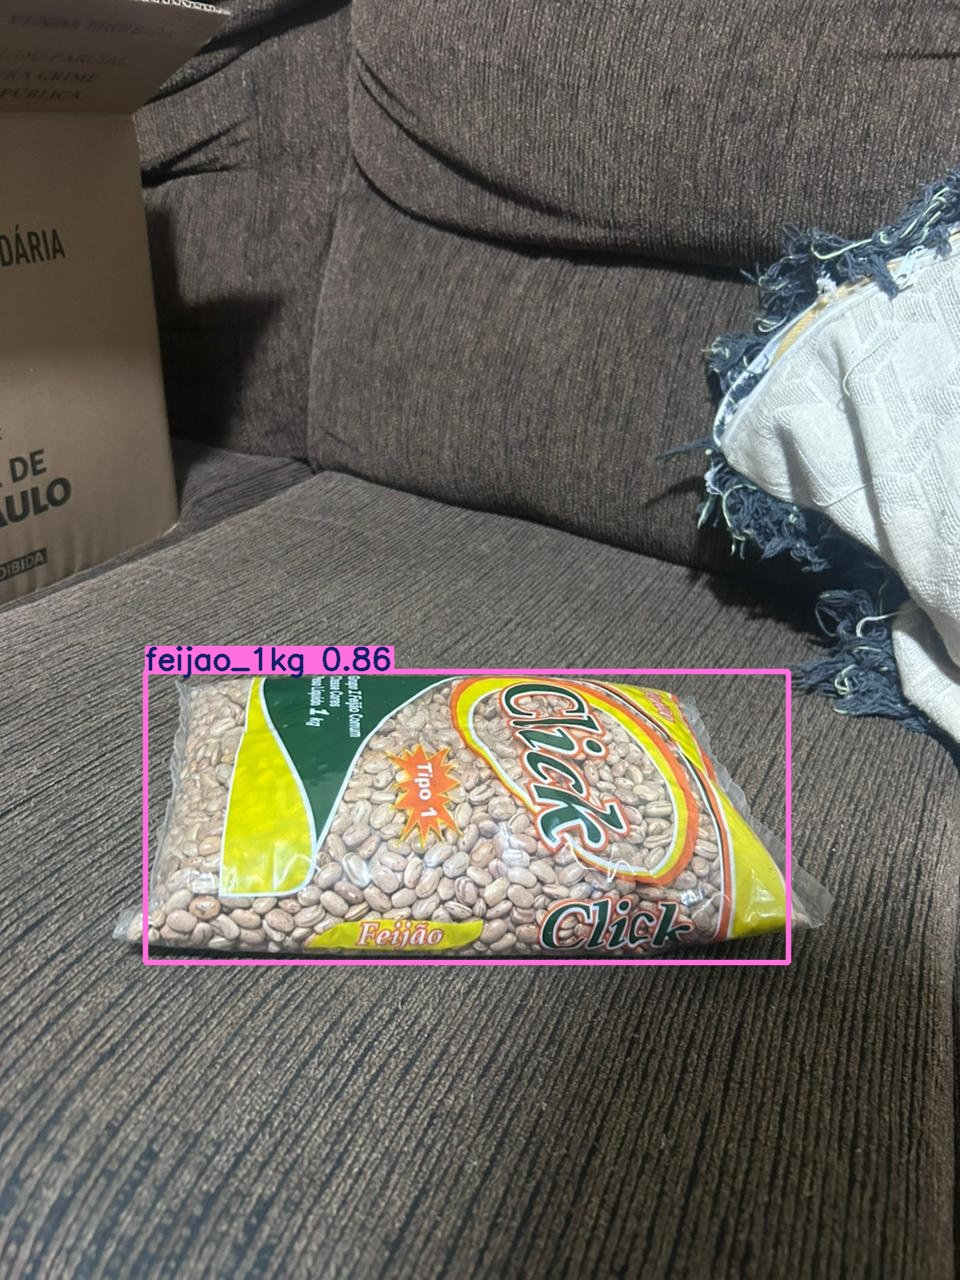

In [7]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')


In [8]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/runs/detect/train /content/my_model

# Zip into "my_model.zip"
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train
%cd /content

/content/my_model
  adding: my_model.pt (deflated 9%)
  adding: train/ (stored 0%)
  adding: train/labels.jpg (deflated 16%)
  adding: train/confusion_matrix.png (deflated 18%)
  adding: train/train_batch1.jpg (deflated 4%)
  adding: train/train_batch2.jpg (deflated 3%)
  adding: train/confusion_matrix_normalized.png (deflated 15%)
  adding: train/BoxP_curve.png (deflated 6%)
  adding: train/val_batch2_pred.jpg (deflated 5%)
  adding: train/BoxPR_curve.png (deflated 11%)
  adding: train/BoxF1_curve.png (deflated 4%)
  adding: train/val_batch0_pred.jpg (deflated 10%)
  adding: train/weights/ (stored 0%)
  adding: train/weights/best.pt (deflated 9%)
  adding: train/weights/last.pt (deflated 9%)
  adding: train/results.csv (deflated 63%)
  adding: train/train_batch0.jpg (deflated 3%)
  adding: train/val_batch1_pred.jpg (deflated 5%)
  adding: train/args.yaml (deflated 53%)
  adding: train/results.png (deflated 7%)
  adding: train/BoxR_curve.png (deflated 6%)
  adding: train/val_batch0_lab

In [9]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>